In [15]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

PROJECT_ID = "fyxical-poc"
DATASET    = "fyxical_poc"
client     = bigquery.Client(project=PROJECT_ID)

df = client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.patient_pathways`").to_dataframe()
print(f"Rows: {len(df)}")
print(df["recommended_pathway"].value_counts().to_string())

Rows: 500
recommended_pathway
CHRONIC           296
ACUTE_SEVERE       76
SUBACUTE           67
ACUTE_MILD_MOD     61


In [16]:
# Acronym reference

ACRONYMS_CLINICAL = {
    "OSW"  : "Oswestry Disability Index — 0-100% disability scale used as a "
              "decision variable. Minimal 0-20% / Moderate 21-40% / "
              "Severe 41-60% / Crippled 61-80% / Bed-bound 81-100%.",
    "VAS"  : "Visual Analogue Scale — pain score 0-10 used as a decision variable. "
              "Mild 0-3 / Moderate 4-6 / Severe 7-10.",
    "ML"   : "Machine Learning — logistic regression trained to replicate rule engine.",
    "LR"   : "Logistic Regression — multiclass classification algorithm used here.",
    "HITL" : "Human-in-the-Loop — planned validation where a licensed PT "
              "independently labels edge cases as clinician-derived ground truth.",
    "POC"  : "Proof of Concept — this project stage. Not validated for clinical use.",
}

ACRONYMS_PATHWAYS = {
    "ACUTE_MILD_MOD" : "Acute + Mild/Moderate  — Pain score 0-6, Duration <2 weeks",
    "ACUTE_SEVERE"   : "Acute + Severe         — Pain score 7-10, Duration <2 weeks",
    "SUBACUTE"       : "Subacute               — Duration 2-12 weeks, any severity",
    "CHRONIC"        : "Chronic / High Burden  — Duration >12 weeks OR high OSW disability",
}

print("=" * 65)
print("  ACRONYM REFERENCE — Notebook 04")
print("=" * 65)

print("\n── Clinical & Project Terms ────────────────────────────────")
for code, desc in ACRONYMS_CLINICAL.items():
    print(f"\n  {code}")
    words = desc.split()
    line = "    "
    for word in words:
        if len(line) + len(word) + 1 > 64:
            print(line)
            line = "    " + word + " "
        else:
            line += word + " "
    print(line.rstrip())

print("\n── Pathway Codes (target variable) ─────────────────────────")
for code, desc in ACRONYMS_PATHWAYS.items():
    print(f"  {code:<16} {desc}")

print("\n" + "=" * 65)

  ACRONYM REFERENCE — Notebook 04

── Clinical & Project Terms ────────────────────────────────

  OSW
    Oswestry Disability Index — 0-100% disability scale used as 
    a decision variable. Minimal 0-20% / Moderate 21-40% / 
    Severe 41-60% / Crippled 61-80% / Bed-bound 81-100%.

  VAS
    Visual Analogue Scale — pain score 0-10 used as a decision 
    variable. Mild 0-3 / Moderate 4-6 / Severe 7-10.

  ML
    Machine Learning — logistic regression trained to replicate 
    rule engine.

  LR
    Logistic Regression — multiclass classification algorithm 
    used here.

  HITL
    Human-in-the-Loop — planned validation where a licensed PT 
    independently labels edge cases as clinician-derived ground 
    truth.

  POC
    Proof of Concept — this project stage. Not validated for 
    clinical use.

── Pathway Codes (target variable) ─────────────────────────
  ACUTE_MILD_MOD   Acute + Mild/Moderate  — Pain score 0-6, Duration <2 weeks
  ACUTE_SEVERE     Acute + Severe         — 

In [17]:
# Feature Engineering

dur_order  = [["Acute","Subacute","Chronic"]]
enc_dur    = OrdinalEncoder(categories=dur_order)
df["pain_duration_enc"] = enc_dur.fit_transform(df[["pain_duration_category"]])

pain_order = [["Mild","Moderate","Severe"]]
enc_pain   = OrdinalEncoder(categories=pain_order)
df["pain_severity_enc"] = enc_pain.fit_transform(df[["pain_severity_category"]])

osw_order  = [["Minimal","Moderate","Severe","Crippled","Bed-bound"]]
enc_osw    = OrdinalEncoder(categories=osw_order)
df["osw_category_enc"]  = enc_osw.fit_transform(df[["osw_baseline_disability_category"]])

print("Ordinal encodings applied:")
print(f"  pain_duration  : {dict(zip(dur_order[0],  range(len(dur_order[0]))))}")
print(f"  pain_severity  : {dict(zip(pain_order[0], range(len(pain_order[0]))))}")
print(f"  osw_category   : {dict(zip(osw_order[0],  range(len(osw_order[0]))))}")

Ordinal encodings applied:
  pain_duration  : {'Acute': 0, 'Subacute': 1, 'Chronic': 2}
  pain_severity  : {'Mild': 0, 'Moderate': 1, 'Severe': 2}
  osw_category   : {'Minimal': 0, 'Moderate': 1, 'Severe': 2, 'Crippled': 3, 'Bed-bound': 4}


In [18]:
# Train / Test Split

feature_cols = [
    "pain_duration_weeks",
    "pain_severity_score_0_10",
    "osw_baseline_percent_disability",
]

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42,
    stratify=df["recommended_pathway"]
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(df.loc[train_idx, feature_cols].values)
X_test  = scaler.transform(df.loc[test_idx,  feature_cols].values)
y_train = df.loc[train_idx, "recommended_pathway"].values
y_test  = df.loc[test_idx,  "recommended_pathway"].values

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features         : {feature_cols}")
print()
print("Class distribution — test set:")
print(pd.Series(y_test).value_counts().to_string())

Training samples : 400
Test samples     : 100
Features         : ['pain_duration_weeks', 'pain_severity_score_0_10', 'osw_baseline_percent_disability']

Class distribution — test set:
CHRONIC           59
ACUTE_SEVERE      15
SUBACUTE          14
ACUTE_MILD_MOD    12


In [19]:
# Train model

model = LogisticRegression(
    max_iter=1000, solver="lbfgs", C=1.0, random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}  ({acc*100:.1f}%)")
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.8100  (81.0%)

                precision    recall  f1-score   support

ACUTE_MILD_MOD       0.92      1.00      0.96        12
  ACUTE_SEVERE       0.75      1.00      0.86        15
       CHRONIC       0.85      0.85      0.85        59
      SUBACUTE       0.50      0.29      0.36        14

      accuracy                           0.81       100
     macro avg       0.76      0.78      0.76       100
  weighted avg       0.79      0.81      0.79       100



In [23]:
# Model framing

print(f"""
Model Validation: Corrected Framing
======================================

Current POC Result:
  Accuracy ({acc*100:.1f}%) = agreement with rule-assigned labels on held-out
  test set (n={len(y_test)}). This reflects how consistently the model
  replicates the rule engine logic — NOT clinical predictive validity.

Why this distinction matters:
  Labels were generated by the rule engine using three variables:
    - pain_duration_weeks
    - pain_severity_score_0_10
    - osw_baseline_percent_disability
  High accuracy means the model learned those rules successfully.
  It does NOT mean the rules themselves produce good patient outcomes.

What this POC model CAN claim:
  + Rule logic is consistent and learnable across unseen patients
  + Pathway assignment can be automated at scale without the rule engine
  + Feature importance is interpretable (see coefficient heatmap below)
  + Foundation is in place for clinical validation once real data exists

What this POC model CANNOT claim:
  - Predictive validity against real patient recovery outcomes
  - Clinical superiority over standard PT triage
  - Generalisability to real patient populations

Planned upgrade — HITL Validation (see Notebook 05 roadmap):
  A licensed PT on our team will independently label n=50-75
  edge cases blind to rule outputs. Model will be re-evaluated
  against PT labels, converting the accuracy metric from
  rule-agreement to clinical-expert-agreement.
""")


Model Validation: Corrected Framing

Current POC Result:
  Accuracy (81.0%) = agreement with rule-assigned labels on held-out
  test set (n=100). This reflects how consistently the model
  replicates the rule engine logic — NOT clinical predictive validity.

Why this distinction matters:
  Labels were generated by the rule engine using three variables:
    - pain_duration_weeks
    - pain_severity_score_0_10
    - osw_baseline_percent_disability
  High accuracy means the model learned those rules successfully.
  It does NOT mean the rules themselves produce good patient outcomes.

What this POC model CAN claim:
  + Rule logic is consistent and learnable across unseen patients
  + Pathway assignment can be automated at scale without the rule engine
  + Feature importance is interpretable (see coefficient heatmap below)
  + Foundation is in place for clinical validation once real data exists

What this POC model CANNOT claim:
  - Predictive validity against real patient recovery outcome

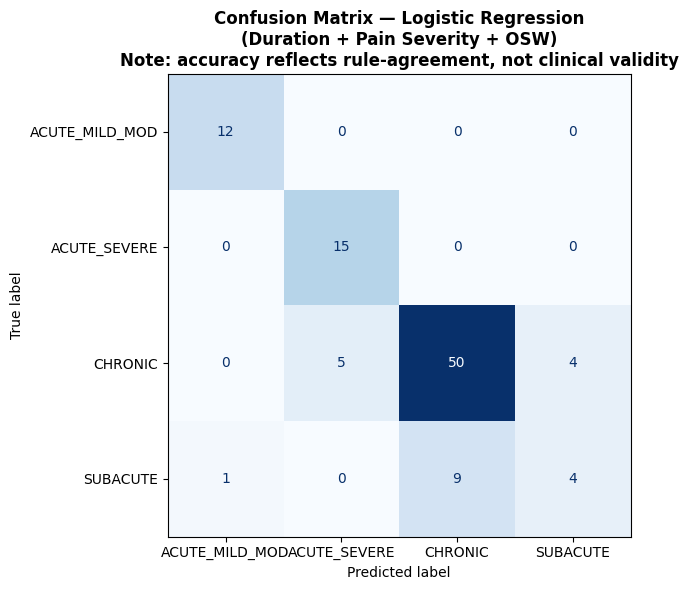

In [24]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(
    "Confusion Matrix — Logistic Regression\n"
    "(Duration + Pain Severity + OSW)\n"
    "Note: accuracy reflects rule-agreement, not clinical validity",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Per-class recall - clinical priority framing

from sklearn.metrics import classification_report
import warnings

report = classification_report(y_test, y_pred, output_dict=True)
recall_df = pd.DataFrame({
    "Pathway"  : list(model.classes_),
    "Recall"   : [report[c]["recall"]   for c in model.classes_],
    "Precision": [report[c]["precision"] for c in model.classes_],
    "F1"       : [report[c]["f1-score"]  for c in model.classes_],
    "Support"  : [report[c]["support"]   for c in model.classes_],
    "Clinical Priority": ["HIGH", "HIGH", "STANDARD", "STANDARD"]
})

print("Per-Class Performance — Clinical Priority View")
print("=" * 60)
print(recall_df.to_string(index=False))
print()
print("HIGH priority pathways (Chronic, Acute Severe) must maintain")
print("high recall — under-treatment errors carry the greatest clinical risk.")

Per-Class Performance — Clinical Priority View
       Pathway   Recall  Precision       F1  Support Clinical Priority
ACUTE_MILD_MOD 1.000000   0.923077 0.960000     12.0              HIGH
  ACUTE_SEVERE 1.000000   0.750000 0.857143     15.0              HIGH
       CHRONIC 0.847458   0.847458 0.847458     59.0          STANDARD
      SUBACUTE 0.285714   0.500000 0.363636     14.0          STANDARD

HIGH priority pathways (Chronic, Acute Severe) must maintain
high recall — under-treatment errors carry the greatest clinical risk.


In [26]:
# Cost-sensitive framework - Phase 3 placeholder
#
# In the current POC, all misclassification errors are treated equally.
# This is not clinically appropriate: assigning a Chronic patient to
# Acute Mild/Moderate (under-treatment) carries far greater risk than
# the reverse.
#
# Phase 3 implementation: refit the model with class_weight to penalise
# under-treatment errors more heavily.
#
# Uncomment when independent clinical outcome labels are available:
#
# from sklearn.utils.class_weight import compute_class_weight
# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=np.unique(y_train),
#     y=y_train
# )
# class_weight_dict = dict(zip(np.unique(y_train), weights))
#
# model_weighted = LogisticRegression(
#     max_iter=1000, solver="lbfgs", C=1.0,
#     class_weight=class_weight_dict, random_state=42
# )
# model_weighted.fit(X_train, y_train)
#
# NOTE: Applying cost-sensitive weighting to rule-generated labels would
# not improve clinical validity — it would only change which rules the
# model prioritises replicating. This cell is a Phase 3 placeholder only.

print("Cost-sensitive framework: Phase 3 placeholder — see comments above.")
print("Not activated in POC: labels are rule-generated, not clinical outcomes.")

Cost-sensitive framework: Phase 3 placeholder — see comments above.
Not activated in POC: labels are rule-generated, not clinical outcomes.


In [27]:
# Cross-validation - rule replication consistency check

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, solver="lbfgs", C=1.0, random_state=42),
    scaler.fit_transform(df[feature_cols].values),
    df["recommended_pathway"].values,
    cv=cv, scoring="accuracy"
)

print("5-Fold Cross-Validation — Rule Replication Accuracy")
print("=" * 45)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s*100:.1f}%")
print(f"  Mean : {cv_scores.mean()*100:.1f}%  (+/- {cv_scores.std()*100:.1f}%)")
print()
print("Consistent CV scores confirm rule logic is stable and learnable.")
print("NOTE: this measures rule-agreement consistency, not clinical validity.")

5-Fold Cross-Validation — Rule Replication Accuracy
  Fold 1: 88.0%
  Fold 2: 87.0%
  Fold 3: 91.0%
  Fold 4: 84.0%
  Fold 5: 88.0%
  Mean : 87.6%  (+/- 2.2%)

Consistent CV scores confirm rule logic is stable and learnable.
NOTE: this measures rule-agreement consistency, not clinical validity.


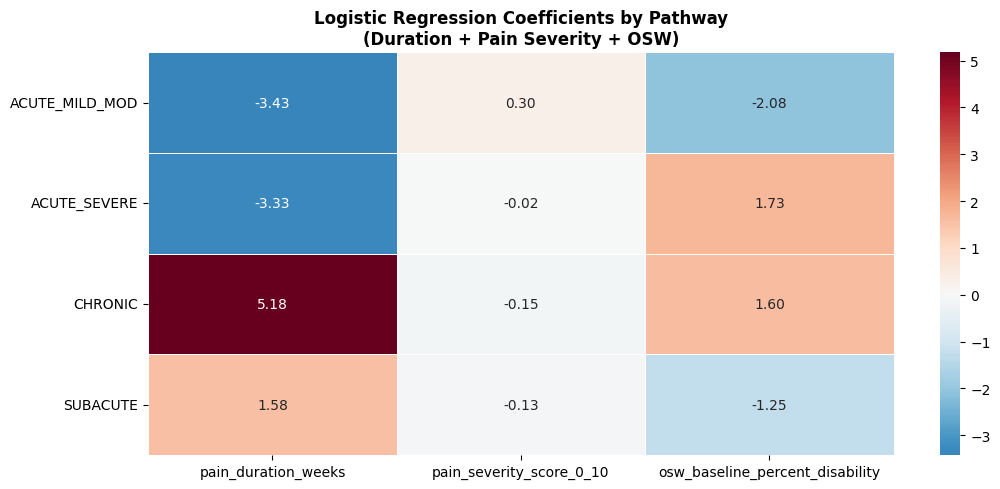

In [28]:
# Feature coefficients heatmap

coef_df = pd.DataFrame(model.coef_, columns=feature_cols, index=model.classes_)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_title(
    "Logistic Regression Coefficients by Pathway\n"
    "(Duration + Pain Severity + OSW)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("feature_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# Export predictions to BigQuery

from google.cloud.bigquery import LoadJobConfig, WriteDisposition

df_export = df.loc[test_idx].copy()
df_export["predicted_pathway"]  = model.predict(X_test)
df_export["prediction_correct"] = (
    df_export["predicted_pathway"] == df_export["recommended_pathway"]
)

job_config = LoadJobConfig(write_disposition=WriteDisposition.WRITE_TRUNCATE, autodetect=True)
job = client.load_table_from_dataframe(
    df_export, f"{PROJECT_ID}.{DATASET}.model_predictions", job_config=job_config
)
job.result()
print(f"Exported {len(df_export)} predictions → model_predictions")
print("Note: predicted_pathway reflects rule-replication, not clinical outcomes.")

Exported 100 predictions → model_predictions
Note: predicted_pathway reflects rule-replication, not clinical outcomes.
